### 1. analytical solution to the regression problem
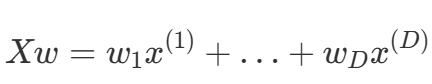
где x1...xD - столбцы матрицы X - признаки

найти линейную комбинацию столбцов x1...xD, которая наилучшим способом приближает столбец y по евклидовой норме – то есть найти проекцию вектора y на подпространство, образованное векторами x1...xD

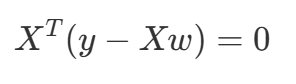
получаем 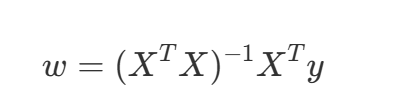

### 2. What changes in the solution when L1 and L2 regularizations are added to the loss function

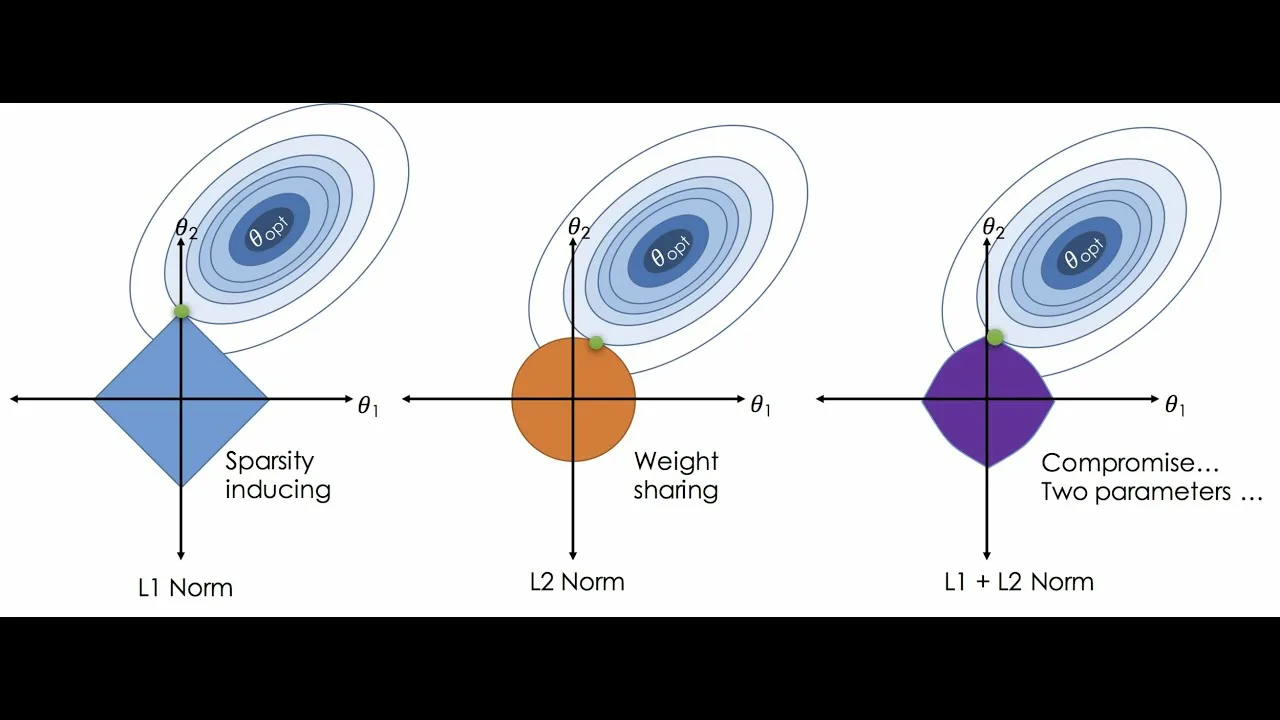

##### L2-регуляризация (Ridge):


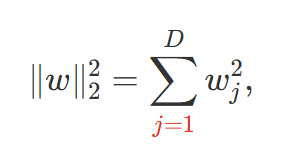

Функция потерь:<br>
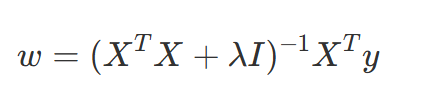

L2-регуляризация справляется с переобучением и делает решение устойчивее.



##### L1-регуляризация (Lasso):

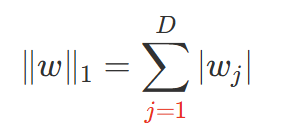

Функция потерь:

$$
L(\mathbf{w}) = \frac{1}{2n} \|\mathbf{Xw} - \mathbf{y}\|^2 + \lambda \|\mathbf{w}\|_1
$$


### 3. Explain why L1 regularization is often used to select features


L1-регуляризация часто используется для отбора признаков, так как она добавляет к функции потерь штраф, который равен сумме абсолютных значений весов модели. В результате оптимизации многие веса признаков становятся равными нулю, что фактически исключает эти признаки из модели.

### 4.
 Чтобы модели могли учитывать нелинейные зависимости, можно использовать:

- **Полиномиальные признаки**:
  $$
  x_1, x_2 \rightarrow x_1, x_2, x_1^2, x_2^2, x_1x_2, \ldots
  $$
  Модель остаётся линейной по параметрам, но может аппроксимировать нелинейности. (с заданной степенью degree)


- **Функции от признаков**:
  $$
  \log(x), \sin(x), \exp(x)
  $$


### Introduction

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import lightgbm
import scipy
import statsmodels.api as sm
from collections import Counter
from sklearn.metrics import mean_absolute_error as MAE 
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import r2_score as R2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

In [34]:
train=pd.read_json('../datasets/train.json')
test=pd.read_json('../datasets/test.json')

In [35]:
train=train[(train['price']>np.percentile(train['price'], 1)) & (train['price']<np.percentile(train['price'],99))]

In [36]:
train['interest_level'].replace({'low': 0, 'medium': 1, 'high' :2}, inplace=True)
train.head()

/tmp/ipykernel_1449/720537723.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['interest_level'].replace({'low': 0, 'medium': 1, 'high' :2}, inplace=True)
/tmp/ipykernel_1449/720537723.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['interest_level'].replace({'low': 0, 'medium': 1

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,1
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,1
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,1
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,0


### Intro data analysis part 2

In [37]:
features=train['features']
features.iloc[:5]

4     [Dining Room, Pre-War, Laundry in Building, Di...
6     [Doorman, Elevator, Laundry in Building, Dishw...
9     [Doorman, Elevator, Laundry in Building, Laund...
10                                                   []
15    [Doorman, Elevator, Fitness Center, Laundry in...
Name: features, dtype: object

In [38]:
all_features=[]
for line in features:
    all_features.extend(line)

unique features:

In [39]:
len(set(all_features))

1539

In [40]:
top_features=Counter(all_features)
top_features.most_common(20)

[('Elevator', 25375),
 ('Hardwood Floors', 23146),
 ('Cats Allowed', 23135),
 ('Dogs Allowed', 21652),
 ('Doorman', 20479),
 ('Dishwasher', 20081),
 ('No Fee', 17793),
 ('Laundry in Building', 16082),
 ('Fitness Center', 12989),
 ('Pre-War', 8971),
 ('Laundry in Unit', 8437),
 ('Roof Deck', 6417),
 ('Outdoor Space', 5132),
 ('Dining Room', 4890),
 ('High Speed Internet', 4223),
 ('Balcony', 2898),
 ('Swimming Pool', 2643),
 ('Laundry In Building', 2564),
 ('New Construction', 2504),
 ('Terrace', 2177)]

In [41]:
common_features=[f for f,count in top_features.most_common(20)]
common_features #features_list

['Elevator',
 'Hardwood Floors',
 'Cats Allowed',
 'Dogs Allowed',
 'Doorman',
 'Dishwasher',
 'No Fee',
 'Laundry in Building',
 'Fitness Center',
 'Pre-War',
 'Laundry in Unit',
 'Roof Deck',
 'Outdoor Space',
 'Dining Room',
 'High Speed Internet',
 'Balcony',
 'Swimming Pool',
 'Laundry In Building',
 'New Construction',
 'Terrace']

In [42]:
train_df=train[['bathrooms', 'bedrooms', 'interest_level', 'features', 'price']].copy()
for f in common_features:
    train_df[f]=train_df['features'].apply(lambda x: 1 if f in x else 0)
train_df.drop(columns='features', inplace=True)

train_df.head()

,bathrooms,bedrooms,interest_level,price,Elevator,Hardwood Floors,Cats Allowed,Dogs Allowed,Doorman,Dishwasher,...,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
4,1.0,1,1,2400,0,1,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,0,3800,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,1,3495,1,1,0,0,1,1,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,1,3000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,0,2795,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


23 features and 1 target(price)

### Linear regression - analytical solution and non-stohastic gradient descent way

In [43]:
class LinearRegressionAanalytical:
    # def fit(self, x,y):
    #     X = np.insert(x, 0, 1, axis=1) #adding bias
    #     xt_x_inv=np.linalg.inv(np.matmul(np.transpose(X),X))
    #     weights=np.matmul(xt_x_inv,np.transpose(X),y)
    #     self.bias, self.weights = weights[0], weights[1:]

    def fit(self, x, y):  #with short numpy form
        X = np.insert(x, 0, 1, axis=1) #adding bias
        xt_x_inv=np.linalg.inv(X.T @ X) #(x transponced * x)^-1
        weights=xt_x_inv @ X.T @ y #(x transponced * x)^-1 * x_transpon * y
        self.bias, self.weights = weights[0], weights[1:]  #bias -сдвиг, weights-features

    def predict(self, X_test):
        return X_test @ self.weights + self.bias

algorithm of gradient descent:
1. w = random_normal()             # можно пробовать и другие виды инициализации
2. repeat S times:                 # другой вариант: while abs(err) > tolerance
3.   f = X.dot(w)                 # посчитать предсказание
4.   err = f - y                  # посчитать ошибку
5.   grad = 2 * X.T.dot(err) / N  # посчитать градиент
6.   w -= alpha * grad            # обновить веса


In [44]:
class LRegressionGradientDescent:
    def __init__(self, learning_rate=0.01, epochs=1000, tolerance=1e-8):
        self.learning_rate=learning_rate #step
        self.epochs=epochs #number of repetitions
        self.tolerance=tolerance
    def fit(self, X, y):
        n_samples, n_features=X.shape
        self.bias, self.weights=0, np.zeros(n_features) #init of bias and weights
        #gradient descent
        for i in range(self.epochs):
            y_pred = (X @ self.weights) + self.bias #calculating of predicton
            err = y_pred - y #calculating of an error
            grad_w=(1/n_samples) * (X.T @ err) #gradient for weights
            grad_b=(1/n_samples) * np.sum(err) #gradient for bias
            self.weights -= self.learning_rate *grad_w
            self.bias -= self.learning_rate *grad_b
    def predict(self, X_test):
        return (X_test @ self.weights) +self.bias

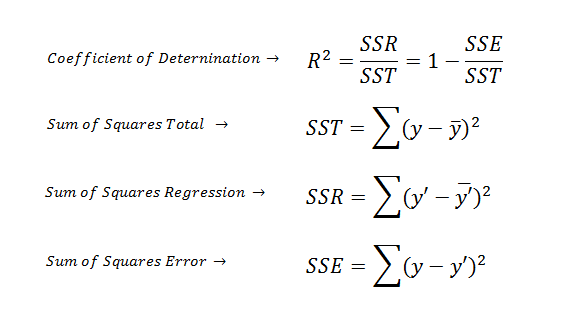

In [45]:
# R^2 score(metric)
def r_squared(y_true, y_pred):
    ssr = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ssr / sst)

Testing

In [46]:
X=train_df.drop(columns='price')
y=train_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

#analytical
lr_analytical=LinearRegressionAanalytical()
lr_analytical.fit(X_train, y_train)
y_pred_train_lr_analytical=lr_analytical.predict(X_train)
y_pred_test_lr_analytical=lr_analytical.predict(X_test)

#gradien descent
lr_gd=LRegressionGradientDescent(learning_rate=0.0001, epochs=10000)
lr_gd.fit(X_train, y_train)
y_pred_train_lr_gd=lr_gd.predict(X_train)
y_pred_test_lr_gd=lr_gd.predict(X_test)


In [47]:
results_metrics=pd.DataFrame(columns=['model', 'MAE_train','MAE_test', 'RMSE_train', 'RMSE_test', 'R2_train','R2_test'])

In [48]:
#metrics for analytical linear regression
mae_lr_analytical_train=MAE(y_train, y_pred_train_lr_analytical)
mae_lr_analytical_test=MAE(y_test, y_pred_test_lr_analytical)
mse_lr_analytical_train=np.sqrt(MSE(y_train, y_pred_train_lr_analytical))
mse_lr_analytical_test=np.sqrt(MSE(y_test, y_pred_test_lr_analytical))
r2_lr_analytical_train=R2(y_train, y_pred_train_lr_analytical)
r2_lr_analytical_test=R2(y_test, y_pred_test_lr_analytical)
results_metrics.loc[len(results_metrics)]=['Analytical', mae_lr_analytical_train, mae_lr_analytical_test, mse_lr_analytical_train,mse_lr_analytical_test, r2_lr_analytical_train, r2_lr_analytical_test]
results_metrics

,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Analytical,687.030471,689.010155,996.991413,994.581205,0.602062,0.616495


In [49]:
#testing r2 function
r2_custom_train=r_squared(y_train, y_pred_train_lr_analytical)
r2_custom_test=r_squared(y_test, y_pred_test_lr_analytical)
print(r2_custom_train, r2_custom_test)

0.6020619693126079 0.616495015905854


In [50]:
#metrics for linear regression with gradient sedcent
mae_lr_gd_train=MAE(y_train, y_pred_train_lr_gd)
mae_lr_gd_test=MAE(y_test, y_pred_test_lr_gd)
mse_lr_gd_train=np.sqrt(MSE(y_train, y_pred_train_lr_gd))
mse_lr_gd_test=np.sqrt(MSE(y_test, y_pred_test_lr_gd))
r2_lr_gd_train=R2(y_train, y_pred_train_lr_gd)
r2_lr_gd_test=R2(y_test, y_pred_test_lr_gd)
results_metrics.loc[len(results_metrics)]=['Gradient descent', mae_lr_gd_train, mae_lr_gd_test, mse_lr_gd_train,mse_lr_gd_test, r2_lr_gd_train, r2_lr_gd_test]
results_metrics

,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Analytical,687.030471,689.010155,996.991413,994.581205,0.602062,0.616495
1,Gradient descent,810.337110,823.396998,1150.138498,1159.997684,0.470418,0.478319


In [51]:
#testing r2 function
r2_custom_train2=r_squared(y_train, y_pred_train_lr_gd)
r2_custom_test2=r_squared(y_test, y_pred_test_lr_gd)
print(r2_custom_train2, r2_custom_test2)

0.47041839392360085 0.47831931118161397


In [52]:
lr_basic=LinearRegression()
lr_basic.fit(X_train, y_train)
y_pred_train_lr_basic=lr_basic.predict(X_train)
y_pred_test_lr_basic=lr_basic.predict(X_test)

In [53]:
#metrics for linear regression from slkearn
mae_lr_basic_train=MAE(y_train, y_pred_train_lr_basic)
mae_lr_basic_test=MAE(y_test, y_pred_test_lr_basic)
mse_lr_basic_train=np.sqrt(MSE(y_train, y_pred_train_lr_basic))
mse_lr_basic_test=np.sqrt(MSE(y_test, y_pred_test_lr_basic))
r2_lr_basic_train=R2(y_train, y_pred_train_lr_basic)
r2_lr_basic_test=R2(y_test, y_pred_test_lr_basic)
results_metrics.loc[len(results_metrics)]=['Sklearn', mae_lr_basic_train, mae_lr_basic_test, mse_lr_basic_train,mse_lr_basic_test, r2_lr_basic_train, r2_lr_basic_test]
results_metrics

,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Analytical,687.030471,689.010155,996.991413,994.581205,0.602062,0.616495
1,Gradient descent,810.337110,823.396998,1150.138498,1159.997684,0.470418,0.478319
2,Sklearn,687.030471,689.010155,996.991413,994.581205,0.602062,0.616495


### Ridge, Lasso, ElasticNet

In [54]:
class RidgeRegularization:
    def __init__(self, learning_rate=0.01, epochs=1000, alpha=1.0):
        self.learning_rate=learning_rate #step
        self.epochs=epochs #number of repetitions
        self.alpha=alpha
    def fit(self, X, y):
        n_samples, n_features=X.shape
        self.bias, self.weights=0, np.zeros(n_features) #init of bias and weights
        #gradient descent
        for i in range(self.epochs):
            y_pred = (X @ self.weights) + self.bias #calculating of predicton
            err = y_pred - y #calculating of an error
            #adding L2 regulariation
            grad_w=(2/n_samples) * (X.T @ err) + (2*self.alpha*self.weights) #gradient for mse + l2 reg(updating weights)
            grad_b=(2/n_samples) * np.sum(err) #gradient for bias
            self.weights -= self.learning_rate *grad_w
            self.bias -= self.learning_rate *grad_b
    def predict(self, X_test):
        return (X_test @ self.weights) +self.bias

In [55]:
class LassoRegularization:
    def __init__(self, learning_rate=0.01, epochs=1000, alpha=1.0):
        self.learning_rate=learning_rate #step
        self.epochs=epochs #number of repetitions
        self.alpha=alpha
    def fit(self, X, y):
        n_samples, n_features=X.shape
        self.bias=np.mean(y)
        self.weights=np.zeros(n_features) #init of bias and weights
        #gradient descent
        for i in range(self.epochs):
            y_pred = (X @ self.weights) + self.bias #calculating of predicton
            err = y_pred - y #calculating of an error
            #adding L1 regulariation
            grad=(2/n_samples) * (X.T @ err) + self.alpha * np.sign(self.weights)
            grad = np.array(grad)
            grad[0] -= self.alpha * np.sign(self.weights[0])
            self.weights -= self.learning_rate * grad
    def predict(self, X_test):
        return (X_test @ self.weights) +self.bias

In [56]:
class ElasticNetMY:
    def __init__(self, learning_rate=0.01, epochs=1000, l1_ratio=0.5,alpha=1.0):
        self.alpha = alpha  
        self.l1_ratio = l1_ratio  # 0.5 = equal mix
        self.epochs = epochs
        self.learning_rate = learning_rate


    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = np.mean(y)
        
        lambda1 = self.alpha * self.l1_ratio
        lambda2 = self.alpha * (1 - self.l1_ratio)
        
        for _ in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            err=y_pred - y
            grad = (2/n_samples) * (X.T @ err) 
            grad += 2 * lambda2 * self.weights  
            update = self.weights - self.learning_rate * grad
            self.weights = np.sign(update) * np.maximum(
                np.abs(update) - self.learning_rate * lambda1, 
                0
            )
            self.bias -= self.learning_rate * (2/n_samples) * np.sum(y_pred - y) #bias is updated without regularization
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [57]:
def evaluate_model(y_train, y_train_pred, y_test, y_test_pred, name):
    mae_train = MAE(y_train, y_train_pred)
    mae_test = MAE(y_test, y_test_pred)
    rmse_train = np.sqrt(MSE(y_train, y_train_pred))
    rmse_test = np.sqrt(MSE(y_test, y_test_pred))
    r2_train = R2(y_train, y_train_pred)
    r2_test = R2(y_test, y_test_pred)

    return {
        "model": name,
        "mae_train": mae_train, "mae_test": mae_test,
        "rmse_train": rmse_train, "rmse_test": rmse_test,
        "r2_train": r2_train, "r2_test": r2_test
    }

In [58]:
ridge=RidgeRegularization()
ridge.fit(X_train, y_train)
y_pred_train_ridge=ridge.predict(X_train)
y_pred_test_ridge=ridge.predict(X_test)
ridge_metrics=evaluate_model(y_train, y_pred_train_ridge, y_test, y_pred_test_ridge, "ridge")

lasso=LassoRegularization()
lasso.fit(X_train, y_train)
y_pred_train_lasso=lasso.predict(X_train)
y_pred_test_lasso=lasso.predict(X_test)
lasso_metrics=evaluate_model(y_train, y_pred_train_lasso, y_test, y_pred_test_lasso, "lasso")

elastic_net=ElasticNetMY()
elastic_net.fit(X_train, y_train)
y_pred_train_elastic_net=elastic_net.predict(X_train)
y_pred_test_elastic_net=elastic_net.predict(X_test)
elastic_metrics=evaluate_model(y_train, y_pred_train_elastic_net, y_test, y_pred_test_elastic_net, "elastic_net")

In [59]:
#sklearn
# Sklearn Ridge
sk_ridge = Ridge(alpha=1.0)
sk_ridge.fit(X_train, y_train)
sk_ridge_metrics = evaluate_model(y_train, sk_ridge.predict(X_train), y_test, sk_ridge.predict(X_test), "Sklearn Ridge")

# Sklearn Lasso
sk_lasso = Lasso(alpha=0.1, max_iter=1000)
sk_lasso.fit(X_train, y_train)
sk_lasso_metrics = evaluate_model(y_train, sk_lasso.predict(X_train), y_test, sk_lasso.predict(X_test), "Sklearn Lasso")

# Sklearn ElasticNet
sk_enet = ElasticNet(alpha=0.1, l1_ratio=0.5)
sk_enet.fit(X_train, y_train)
sk_enet_metrics = evaluate_model(y_train, sk_enet.predict(X_train), y_test, sk_enet.predict(X_test), "Sklearn ElasticNet")

In [60]:
mae_df=pd.DataFrame(columns=['model', 'train', 'test'])
rmse_df=pd.DataFrame(columns=['model', 'train', 'test'])
r2_df=pd.DataFrame(columns=['model', 'train', 'test'])
for m in [ridge_metrics, lasso_metrics, elastic_metrics, sk_ridge_metrics, sk_lasso_metrics, sk_enet_metrics]:
    mae_df.loc[len(mae_df)] = [m["model"], m["mae_train"], m["mae_test"]]
    rmse_df.loc[len(rmse_df)] = [m["model"], m["rmse_train"], m["rmse_test"]]
    r2_df.loc[len(r2_df)] = [m["model"], m["r2_train"], m["r2_test"]]


In [61]:
mae_df

,model,train,test
0,ridge,843.437175,852.503970
1,lasso,959.845044,969.373382
2,elastic_net,782.512128,791.204671
3,Sklearn Ridge,687.026383,689.007983
4,Sklearn Lasso,686.954576,688.960619
5,Sklearn ElasticNet,689.400127,693.175419


In [62]:
rmse_df

,model,train,test
0,ridge,1233.229123,1249.516138
1,lasso,1287.539711,1297.337263
2,elastic_net,1154.231397,1167.476982
3,Sklearn Ridge,996.991419,994.584120
4,Sklearn Lasso,996.993471,994.604735
5,Sklearn ElasticNet,1009.372018,1011.165845


In [63]:
r2_df

,model,train,test
0,ridge,0.391136,0.394695
1,lasso,0.336327,0.347476
2,elastic_net,0.466643,0.471570
3,Sklearn Ridge,0.602062,0.616493
4,Sklearn Lasso,0.602060,0.616477
5,Sklearn ElasticNet,0.592117,0.603598


### Normalization

Когда надо нормализировать признаки?

1. Модели, которые требуют расчета расстояний между объектами очень чувствительны к масштабу признаков. Это например KNN, k-Means и другие. 
В алгоритмах применяется метод градиентного спуска - если данные приведены к норме схождение происходит лучше

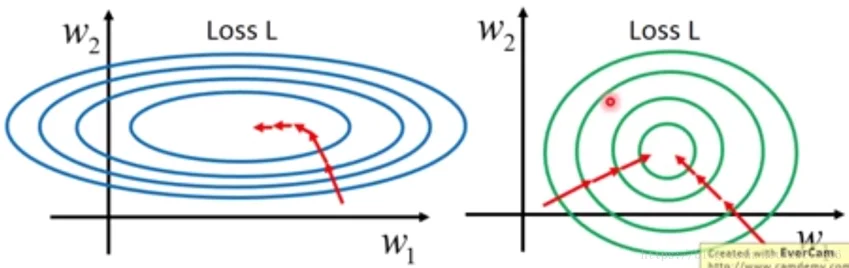

2. Когда признаки имеют разные масштабы.Масштабы могут сильно различаться, и это может повлиять на результат модели. (км-м)

Когда не надо нормализовать:
1. Деревья - они не чувствительны к масштабу
2. Классификаторы, не чувствительные к масштабу, например, наивный байесовский классификатор, который работает с вероятностями.

MinMax Scaler
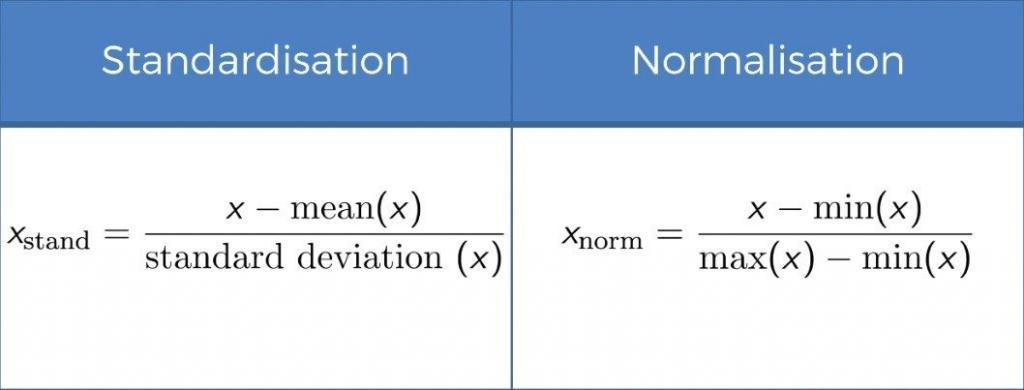

In [64]:
def min_max_scaler_mine(x):
    x_min=np.min(x, axis=0)
    x_max=np.max(x, axis=0)
    x_scaled=(x-x_min)/(x_max-x_min)
    return x_scaled

In [65]:
scaler=MinMaxScaler()
x_train_scaled_minmax=scaler.fit_transform(X_train)
x_test_scaled_minmax=scaler.fit_transform(X_test)


In [66]:
x_train_scaled_mine_minmax=min_max_scaler_mine(X_train)
x_test_scaled_mine_minmax=min_max_scaler_mine(X_test)

let`s compare results of scaling:

In [67]:
display(np.allclose(x_train_scaled_minmax, x_train_scaled_mine_minmax))
display(np.allclose(x_test_scaled_minmax, x_test_scaled_mine_minmax))

True

True

standard scaler

In [68]:
def standard_scaler(x):
    x_mean=np.mean(x, axis=0)
    x_std=np.std(x, axis=0)
    x_scaled=(x-x_mean)/x_std
    return  x_scaled

In [69]:
scaler_std=StandardScaler()
x_train_scaled_std=scaler_std.fit_transform(X_train)
x_test_scaled_std=scaler_std.fit_transform(X_test)

In [70]:
x_train_st_mine=standard_scaler(X_train)
x_test_st_mine=standard_scaler(X_test)

In [71]:
display(np.allclose(x_train_scaled_std, x_train_st_mine))
display(np.allclose(x_test_scaled_std, x_test_st_mine))

True

True

Fit models with normalization

In [72]:
#fitting models with normalised features

lr_minmax=LinearRegression()
lr_minmax.fit(x_train_scaled_minmax, y_train)
y_pred_train_minmax_lr=lr_minmax.predict(x_train_scaled_minmax)
y_pred_test_minmax_lr=lr_minmax.predict(x_test_scaled_minmax)

ridge_minmax=Ridge()
ridge_minmax.fit(x_train_scaled_minmax, y_train)
y_pred_train_minmax_ridge=ridge_minmax.predict(x_train_scaled_minmax)
y_pred_test_minmax_ridge=ridge_minmax.predict(x_test_scaled_minmax)

lasso_minmax=Lasso()
lasso_minmax.fit(x_train_scaled_minmax, y_train)
y_pred_train_minmax_lasso=lasso_minmax.predict(x_train_scaled_minmax)
y_pred_test_minmax_lasso=lasso_minmax.predict(x_test_scaled_minmax)

elastic_minmax=ElasticNet()
elastic_minmax.fit(x_train_scaled_minmax, y_train)
y_pred_train_minmax_elastic=elastic_minmax.predict(x_train_scaled_minmax)
y_pred_test_minmax_elastic=elastic_minmax.predict(x_test_scaled_minmax)


In [73]:
#fitting models with standatisied features

lr_std=LinearRegression()
lr_std.fit(x_train_scaled_std, y_train)
y_pred_train_std_lr=lr_std.predict(x_train_scaled_std)
y_pred_test_std_lr=lr_std.predict(x_test_scaled_std)

ridge_std=Ridge()
ridge_std.fit(x_train_scaled_std, y_train)
y_pred_train_std_ridge=ridge_std.predict(x_train_scaled_std)
y_pred_test_std_ridge=ridge_std.predict(x_test_scaled_std)

lasso_std=Lasso()
lasso_std.fit(x_train_scaled_std, y_train)
y_pred_train_std_lasso=lasso_std.predict(x_train_scaled_std)
y_pred_test_std_lasso=lasso_std.predict(x_test_scaled_std)

elastic_std=ElasticNet()
elastic_std.fit(x_train_scaled_std, y_train)
y_pred_train_std_elastic=elastic_std.predict(x_train_scaled_std)
y_pred_test_std_elastic=elastic_std.predict(x_test_scaled_std)


In [74]:
def add_metrics(model_name, y_train, y_test, y_pred_train, y_pred_test):
    mae_train = MAE(y_train, y_pred_train)
    mae_test = MAE(y_test, y_pred_test)

    rmse_train = np.sqrt(MSE(y_train, y_pred_train))
    rmse_test = np.sqrt(MSE(y_test, y_pred_test))

    r2_train = R2(y_train, y_pred_train)
    r2_test = R2(y_test, y_pred_test)

    mae_df.loc[len(mae_df)] = [model_name, mae_train, mae_test]
    rmse_df.loc[len(rmse_df)] = [model_name, rmse_train, rmse_test]
    r2_df.loc[len(r2_df)] = [model_name, r2_train, r2_test]

In [75]:
# MinMaxScaler
models_minmax = [
    (lr_minmax, 'Linear Regression (MinMax)'),
    (ridge_minmax, 'Ridge (MinMax)'),
    (lasso_minmax, 'Lasso (MinMax)'),
    (elastic_minmax, 'ElasticNet (MinMax)')
]

for model, name in models_minmax:
    add_metrics(name, y_train, y_test,
                model.predict(x_train_scaled_minmax),
                model.predict(x_test_scaled_minmax))


In [76]:
# StandardScaler
models_standard = [
    (lr_std, 'Linear Regression (Standard)'),
    (ridge_std, 'Ridge (Standard)'),
    (lasso_std, 'Lasso (Standard)'),
    (elastic_std, 'ElasticNet (Standard)')
]

for model, name in models_standard:
    add_metrics(name, y_train, y_test,
                model.predict(x_train_scaled_std),
                model.predict(x_test_scaled_std))

In [77]:
mae_df

,model,train,test
0,ridge,843.437175,852.503970
1,lasso,959.845044,969.373382
2,elastic_net,782.512128,791.204671
3,Sklearn Ridge,687.026383,689.007983
4,Sklearn Lasso,686.954576,688.960619
5,Sklearn ElasticNet,689.400127,693.175419
6,Linear Regression (MinMax),687.030471,2730.481397
7,Ridge (MinMax),687.156337,2684.507417
8,Lasso (MinMax),686.643240,2633.612745
9,ElasticNet (MinMax),1042.968261,1057.763777


In [78]:
rmse_df

,model,train,test
0,ridge,1233.229123,1249.516138
1,lasso,1287.539711,1297.337263
2,elastic_net,1154.231397,1167.476982
3,Sklearn Ridge,996.991419,994.584120
4,Sklearn Lasso,996.993471,994.604735
5,Sklearn ElasticNet,1009.372018,1011.165845
6,Linear Regression (MinMax),996.991413,3035.443026
7,Ridge (MinMax),997.038846,2985.300186
8,Lasso (MinMax),997.408179,2928.356016
9,ElasticNet (MinMax),1466.888691,1485.482893


In [79]:
r2_df

,model,train,test
0,ridge,0.391136,0.394695
1,lasso,0.336327,0.347476
2,elastic_net,0.466643,0.471570
3,Sklearn Ridge,0.602062,0.616493
4,Sklearn Lasso,0.602060,0.616477
5,Sklearn ElasticNet,0.592117,0.603598
6,Linear Regression (MinMax),0.602062,-2.572191
7,Ridge (MinMax),0.602024,-2.455147
8,Lasso (MinMax),0.601729,-2.324591
9,ElasticNet (MinMax),0.138556,0.144489


### Overfitting 

In [80]:
X_p=train_df[['bathrooms', 'bedrooms', 'interest_level']]
y_p=y
poly=PolynomialFeatures(degree=10)
X_poly=poly.fit_transform(X_p)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_p, test_size=0.2, random_state=21)

In [81]:
#fitting models on polynomial features

lr_poly=LinearRegression()
lr_poly.fit(X_train_poly, y_train_poly)

ridge_poly=Ridge()
ridge_poly.fit(X_train_poly, y_train_poly)


lasso_poly=Lasso()
lasso_poly.fit(X_train_poly, y_train_poly)


elastic_poly=ElasticNet()
elastic_poly.fit(X_train_poly, y_train_poly)


/home/shep_nst/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.078e+10, tolerance: 9.660e+06
  model = cd_fast.enet_coordinate_descent(
/home/shep_nst/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.144e+10, tolerance: 9.660e+06
  model = cd_fast.enet_coordinate_descent(


ElasticNet()

In [82]:
models_poly = [
    (lr_poly, 'Linear Regression(poly)'),
    (ridge_poly, 'Ridge(poly)'),
    (lasso_poly, 'Lasso(poly)'),
    (elastic_poly, 'ElasticNet(poly)')
]

for model, name in models_poly:
    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)
    add_metrics(name, y_train, y_test, y_pred_train, y_pred_test)

### Naive models

In [83]:
mean_y=y_train.mean()
median_y=np.median(y_train)

y_pred_train_mean = np.full_like(y_train, mean_y)
y_pred_test_mean = np.full_like(y_test, mean_y)

y_pred_train_median = np.full_like(y_train, median_y)
y_pred_test_median = np.full_like(y_test, median_y)

In [84]:
add_metrics("Mean model", y_train, y_test, y_pred_train_mean, y_pred_test_mean)
add_metrics("Median model", y_train, y_test, y_pred_train_median, y_pred_test_median)

### RESULTS

MAE

In [85]:
mae_df

,model,train,test
0,ridge,843.437175,852.503970
1,lasso,959.845044,969.373382
2,elastic_net,782.512128,791.204671
3,Sklearn Ridge,687.026383,689.007983
4,Sklearn Lasso,686.954576,688.960619
5,Sklearn ElasticNet,689.400127,693.175419
6,Linear Regression (MinMax),687.030471,2730.481397
7,Ridge (MinMax),687.156337,2684.507417
8,Lasso (MinMax),686.643240,2633.612745
9,ElasticNet (MinMax),1042.968261,1057.763777


RMSE

In [86]:
rmse_df

,model,train,test
0,ridge,1233.229123,1249.516138
1,lasso,1287.539711,1297.337263
2,elastic_net,1154.231397,1167.476982
3,Sklearn Ridge,996.991419,994.584120
4,Sklearn Lasso,996.993471,994.604735
5,Sklearn ElasticNet,1009.372018,1011.165845
6,Linear Regression (MinMax),996.991413,3035.443026
7,Ridge (MinMax),997.038846,2985.300186
8,Lasso (MinMax),997.408179,2928.356016
9,ElasticNet (MinMax),1466.888691,1485.482893


R2-Score

In [87]:
r2_df

,model,train,test
0,ridge,3.911362e-01,0.394695
1,lasso,3.363274e-01,0.347476
2,elastic_net,4.666425e-01,0.471570
3,Sklearn Ridge,6.020620e-01,0.616493
4,Sklearn Lasso,6.020603e-01,0.616477
5,Sklearn ElasticNet,5.921174e-01,0.603598
6,Linear Regression (MinMax),6.020620e-01,-2.572191
7,Ridge (MinMax),6.020241e-01,-2.455147
8,Lasso (MinMax),6.017292e-01,-2.324591
9,ElasticNet (MinMax),1.385562e-01,0.144489


Lasso is a good model, as well as Elastic NEt. Elastic Net is quite stable because it combines L1 and L2 regularizations.